# NfL-iPLA: Non-neurodegenerative clinical categories

Plasma NfL concentrations measured by NfL-iPLA across cerebrovascular, trauma, cardiac, and control groups. Samples were obtained from patients with a range of acute presentations (N = 105; 53M, 56F; median age 52 yr, IQR 36–75, range 16–91) and collected in lithium heparin tubes.

**Pipeline summary:**
1. Load replicate-level raw data
2. Aggregate to per-sample means (groupby `sample_id`, `sex`, `med_abbrev`)
3. Assign clinical category via regex pattern-matching on `med_abbrev` free text
4. Explode multi-category rows (a sample may match more than one category)
5. Drop Renal category (insufficient n for reporting)
6. Plot log10 boxplot + jittered scatter per category


In [1]:
# ── Environment setup ────────────────────────────────────────────────────────
# Adding the parent directory to sys.path allows `from ProxiPal import *`
# regardless of the notebook's working directory.

import sys
from pathlib import Path

module_dir = Path.cwd().parent
sys.path.append(str(module_dir))

from ProxiPal import *
# ProxiPal also imports pandas, numpy, scipy, matplotlib — these are
# available after this line without separate import statements.
# See: https://github.com/jeffsmith8/NfL-iPLA-paper

import re
from collections import OrderedDict
from matplotlib.ticker import LogLocator, FuncFormatter, NullFormatter


OS:				 Windows-11-10.0.26200-SP0
Python version:		 3.12.6 | packaged by conda-forge | (main, Sep 22 2024, 14:01:26) [MSC v.1941 64 bit (AMD64)]
Date and Time:		 2026-06-02 12:26:05
cwd:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\user_documents\NfL-PLA Development Paper\NfL-PLA Development Paper Figure Data\GitHub\NfL-iPLA-paper\NfL-iPLA_trauma
base_path:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal
python_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\python
templates_folder:	 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\templates
data_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\data
samples_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\samples
quality_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\quality
user_downloads:		 C:\Users\smith.j\One

In [2]:
# ── Global rcParams ──────────────────────────────────────────────────────────
# Set once here; never override per-plot. Matches project-wide convention.
# Font sizes are 6 pt throughout (Nature Comms figure requirements).

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial']
plt.rcParams['font.size'] = 6
plt.rcParams['axes.titlesize'] = 6
plt.rcParams['axes.labelsize'] = 6
plt.rcParams['xtick.labelsize'] = 6
plt.rcParams['ytick.labelsize'] = 6
plt.rcParams['legend.fontsize'] = 6
plt.rcParams['scatter.edgecolors'] = 'none'  # suppress default marker edges

# ── Colour palette ────────────────────────────────────────────────────────────
# Okabe-Ito colourblind-safe palette used project-wide.
# Category colours are assigned to maximise perceptual separation.
# 'control' uses black (conventional reference group treatment).

okabe_ito = {
    'orange':         '#E69F00',
    'sky blue':       '#56B4E9',
    'bluish green':   '#009E73',
    'yellow':         '#F0E442',
    'blue':           '#0072B2',
    'vermillion':     '#D55E00',
    'reddish purple': '#CC79A7',
    'black':          '#000000',
}

category_colours = {
    'Cerebrovascular': okabe_ito['blue'],        # #0072B2
    'Cardiac':         okabe_ito['vermillion'],  # #D55E00
    'Trauma':          okabe_ito['bluish green'],# #009E73
    'control':         okabe_ito['black'],       # #000000
}


In [3]:
# ── Load raw data ────────────────────────────────────────────────────────────
# Input: NfL-iPLA_trauma_data.csv (source data file for submission).
# Each row is one replicate measurement for one sample.
# Key columns:
#   sample_id          — unique patient/sample identifier
#   sex                — patient sex
#   age                — patient age (years)
#   med_abbrev         — free-text clinical abbreviation string (e.g. 'MVA; TBI')
#   specimen_type      — e.g. plasma
#   collection_type    — e.g. lithium heparin
#   expt_folder_csv    — experiment batch identifier
#   'SLR; log10(x); exc_std0; ct; raw_ng/L'
#                      — NfL-iPLA result in ng/L after back-calculation
#                        from log10-linearised 4PL fit; std0 replicates excluded

trauma_df = pd.read_csv('NfL-iPLA_trauma_data.csv')
print(trauma_df.shape)
trauma_df.head(1)


(553, 126)


,Unnamed: 0,well,position,target,sample_id,tube_id,rep_id,dilution,var_1,var_2,...,reading (eds; melt curve raw data),temperature (eds; melt curve raw data),fluorescence (eds; melt curve raw data),derivative (eds; melt curve raw data),age,sex,med_abbrev,specimen_type,collection_type,expt_folder_csv
0,196,5,A5,NfL,RMH-P038,NaN,3,5.0,1,0,...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[60.305, 60.797, 61.289, 61.781, 62.272, 62.76...","[3.922, 3.877, 3.822, 3.771, 3.724, 3.678, 3.6...","[0.1, 0.101, 0.101, 0.102, 0.102, 0.102, 0.101...",74.0,F,CVA,plasma,Li Hep blood,230112_e24_kruti


In [4]:
# ── Helper function ──────────────────────────────────────────────────────────
# uniq_join: collapses a Series to a semicolon-separated string of unique
# non-null values. Used during groupby aggregation to preserve metadata
# columns that may have multiple distinct values per sample (e.g. if a sample
# was run across two experiments).

def uniq_join(s: pd.Series) -> str:
    vals = pd.unique(s.dropna())
    return '; '.join(map(str, vals)) if len(vals) else np.nan


# ── Aggregate replicates to per-sample means ──────────────────────────────────
# Replicates (typically duplicate or triplicate) are collapsed to a single row
# per sample by grouping on (sample_id, sex, med_abbrev).
# Summary statistics computed per sample:
#   mean_raw_ng_per_L  — mean NfL concentration across replicates (ng/L)
#   sd_raw_ng_per_L    — SD of replicates (ng/L); reflects intra-sample
#                        repeatability, not biological variation
#   replicates         — number of valid replicate measurements
#   cv_raw_ng_per_L_pct — coefficient of variation (%) across replicates;
#                         NaN if mean == 0 (avoids division-by-zero)
#   age                — median age (invariant within sample, median used
#                         to handle any duplicated metadata rows)
#   specimen_type, collection_type, expt — unique-joined metadata

raw_col = 'SLR; log10(x); exc_std0; ct; raw_ng/L'
grp_cols = ['sample_id', 'sex', 'med_abbrev']

trauma_df_grp = (
    trauma_df
    .groupby(grp_cols, dropna=False)
    .agg(
        age=('age', 'median'),
        specimen_type=('specimen_type', uniq_join),
        collection_type=('collection_type', uniq_join),
        expt=('expt_folder_csv', lambda s: '; '.join(pd.unique(s.dropna()))),
        mean_raw_ng_per_L=(raw_col, 'mean'),
        sd_raw_ng_per_L=(raw_col, 'std'),
        replicates=(raw_col, 'size'),
        cv_raw_ng_per_L_pct=(
            raw_col,
            lambda x: np.nan if x.mean() == 0 else (x.std() / x.mean() * 100)
        )
    )
    .reset_index()
)

print(trauma_df_grp.shape)


(109, 11)


In [5]:
# ── Clinical category annotation ─────────────────────────────────────────────
# med_abbrev is a free-text field containing clinical abbreviations for each
# patient's presentation (e.g. 'MVA; TBI; LOC'). Categories are assigned by
# regex pattern-matching against this string.
#
# Design decisions:
#   - OrderedDict preserves pattern priority (earlier categories take precedence
#     only in the sense that hits are accumulated left-to-right, but ALL matching
#     categories are retained — a sample can be multi-labelled).
#   - Word-boundary anchors (\b) prevent substring false-positives
#     (e.g. 'AS' matching 'NSTEMI' is avoided by \bAS\b).
#   - Rows with no med_abbrev (NaN or blank) are labelled 'control'.
#   - Multi-labelled rows are later exploded to one row per category,
#     so a sample appearing in both Cerebrovascular and Trauma contributes
#     a data point to each group.
#
# Note: SDH (subdural haematoma) and TBI (traumatic brain injury) are listed
# under Cerebrovascular patterns rather than Trauma because the primary
# mechanism involves intracranial pathology. This is a clinical judgement
# call; see figure caption for full abbreviation definitions.

cat_patterns = OrderedDict({
    'Cerebrovascular': [
        r'\bICH\b', r'\bCVA\b', r'\bICA\b', r'\bECR\b', r'\bMCA\b',
        r'\bbasilar\b', r'\bvertebral\b', r'posterior circulation',
        r'\bNIHSS\b', r'\bSAH\b', r'\bSDH\b', r'\bTBI\b',
        r'\binfarct\b', r'\bstroke\b', r'\bhyperdense\b'
    ],
    'Renal': [
        r'\beGFR\b', r'\bESRF\b', r'albumin'
    ],
    'Cardiac': [
        r'\bAF\b', r'\bCCF\b', r'\bIHD\b', r'\bAS\b', r'\bNSTEMI\b',
        r'cardiac arrest'
    ],
    'Trauma': [
        r'\bMVA\b', r'\btrauma\b', r'\bfall\b', r'\babdo injury\b', r'\bassault\b'
    ],
})


def annotate_category(med_abbrev):
    """Assign one or more clinical categories to a med_abbrev string.

    Returns a semicolon-separated string of matched category names,
    or 'control' if med_abbrev is missing or blank.
    All matching categories are returned (not just the first match).
    """
    if pd.isna(med_abbrev) or (isinstance(med_abbrev, str) and med_abbrev.strip() == ''):
        return 'control'
    text = str(med_abbrev)
    hits = [
        cat for cat, patterns in cat_patterns.items()
        if any(re.search(pat, text, flags=re.IGNORECASE) for pat in patterns)
    ]
    return '; '.join(hits)


trauma_df_grp['category'] = trauma_df_grp['med_abbrev'].apply(annotate_category)
print(trauma_df_grp.shape)
trauma_df_grp[['sample_id', 'med_abbrev', 'category']].head(10)


(109, 12)


,sample_id,med_abbrev,category
0,NFL-QC-001,"ICH, eGFR 55",Cerebrovascular; Renal
1,NFL-QC-002,"eGFR>90 , normal Albumin",Renal
2,NFL-QC-003,"CVA, eGFR 80",Cerebrovascular; Renal
3,NFL-QC-004,CVA,Cerebrovascular
4,NFL-QC-005,ICH,Cerebrovascular
5,NFL-QC-006,ICH,Cerebrovascular
6,NFL-QC-007,CVA secondary to ICA dissection,Cerebrovascular
7,NFL-QC-008,ICH,Cerebrovascular
8,NFL-QC-009,ICH,Cerebrovascular
9,NFL-QC-010,ICH,Cerebrovascular


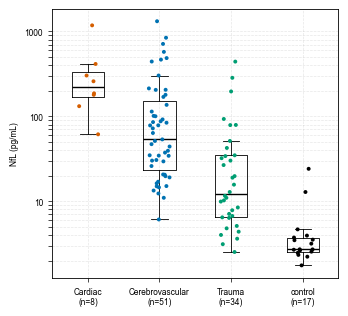

In [8]:
# ── Plot function ─────────────────────────────────────────────────────────────
# Black-outline boxplot + coloured jittered strip per clinical category,
# log10 y-axis. Boxplot provides IQR/median/whisker summary familiar to
# clinician readers. Individual points are the primary data element.
#
# Boxplot parameters:
#   - Whiskers at 1.5×IQR (Tukey convention)
#   - Fliers suppressed (all individual points shown explicitly via scatter)
#   - No fill; black lines at linewidth=0.6
#   - Median line: black, linewidth=1.0
#
# Conventions:
#   - accepts ax argument; no internal tight_layout/savefig
#   - grid: dashed, alpha=0.3, linewidth=0.5
#   - fixed RNG seed for reproducible jitter

okabe_ito = {
    'orange':         '#E69F00',
    'sky blue':       '#56B4E9',
    'bluish green':   '#009E73',
    'yellow':         '#F0E442',
    'blue':           '#0072B2',
    'vermillion':     '#D55E00',
    'reddish purple': '#CC79A7',
    'black':          '#000000',
}

category_colours = {
    'Cerebrovascular': okabe_ito['blue'],
    'Cardiac':         okabe_ito['vermillion'],
    'Trauma':          okabe_ito['bluish green'],
    'control':         okabe_ito['black'],
}


def plot_trauma_categories(ax):
    """Boxplot + strip of NfL-iPLA concentration by clinical category (log10 y-axis)."""

    y_col = (
        'mean_raw_ng_per_L_filtered'
        if 'mean_raw_ng_per_L_filtered' in trauma_df_grp.columns
        else 'mean_raw_ng_per_L'
    )

    # ── Data preparation ──────────────────────────────────────────────────────
    df_plot = trauma_df_grp.copy()
    df_plot['category'] = df_plot['category'].fillna('control').astype(str)

    # Explode multi-label categories: 'Cardiac; Trauma' → two rows
    df_plot = (
        df_plot
        .assign(category=df_plot['category'].str.split(r'\s*;\s*'))
        .explode('category')
    )
    df_plot['category'] = df_plot['category'].str.strip()
    df_plot = df_plot[(df_plot['category'] != '') & df_plot[y_col].notna()]
    df_plot = df_plot[~df_plot['category'].str.casefold().eq('renal')]
    df_plot = df_plot[df_plot[y_col] > 0].copy()

    # Order by descending median NfL
    order = (
        df_plot.groupby('category')[y_col]
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    counts = df_plot.groupby('category')[y_col].size().reindex(order)
    colours = [category_colours.get(c, okabe_ito['reddish purple']) for c in order]
    data = [df_plot.loc[df_plot['category'] == c, y_col].values for c in order]

    # ── Boxplot ───────────────────────────────────────────────────────────────
    bp = ax.boxplot(
        data,
        whis=1.5,
        showfliers=False,
        patch_artist=False,
        boxprops=dict(linewidth=0.6, color='black'),
        whiskerprops=dict(linewidth=0.6, color='black'),
        capprops=dict(linewidth=0.6, color='black'),
        medianprops=dict(linewidth=1.0, color='black'),
    )

    # ── Jittered scatter overlay ──────────────────────────────────────────────
    rng = np.random.default_rng(seed=42)
    for x, vals, colour in zip(np.arange(1, len(order) + 1), data, colours):
        jitter = (rng.random(len(vals)) - 0.5) * 0.30
        ax.scatter(
            np.full(len(vals), x) + jitter,
            vals,
            s=8,
            color=colour,
            edgecolors='none',
            zorder=3,
        )

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_yscale('log')
    ax.yaxis.set_major_locator(LogLocator(base=10, numticks=10))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:g}'))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs='auto', numticks=10))
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.set_xticks(np.arange(1, len(order) + 1))
    ax.set_xticklabels(
        [f'{c}\n(n={int(counts[c])})' for c in order],
        fontsize=6,
    )
    ax.set_xlim(0.5, len(order) + 0.5)
    ax.set_ylabel('NfL (pg/mL)')
    ax.set_xlabel('')
    ax.tick_params(which='both', direction='out', length=3, width=0.5)
    ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)
    ax.spines[['left', 'bottom', 'top', 'right']].set_linewidth(0.6)


# ── Figure assembly ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(88/25.4, 80/25.4))  # single-column

plot_trauma_categories(ax)

plt.tight_layout()
plt.savefig('NfL-iPLA_trauma.svg', dpi=300, bbox_inches='tight')
plt.show()